# TwoStageSignalAgent Lambda-Alpha Search

This notebook summarizes the two-stage signal model grid search with:

\[
\tau = 2/3 \approx 0.6667
\]

fixed, and with early ambiguity preservation removed:

\[
\eta = 0
\]

The fitted grid varies:

\[
\lambda \quad \text{and} \quad \alpha
\]

where \(\lambda\) controls posterior weight in committed goal selection, and \(\alpha\) controls signaling strength.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / 'client').exists() and (candidate / 'dataAnalysis').exists():
        PROJECT_ROOT = candidate
        break

OUT = PROJECT_ROOT / 'dataAnalysis' / 'model_model' / 'two_stage_signal_agent' / 'outputs' / 'two_stage_signal_lambda_alpha_fit_tau2over3_eta0'
RAW = PROJECT_ROOT / 'dataAnalysis' / 'raw_data' / 'model_model_simulations' / 'two_stage_signal_agent' / 'lambda_alpha_tau2over3_eta0'

summary = json.loads((OUT / 'two_stage_signal_4param_fit_summary.json').read_text())
grid = pd.read_csv(OUT / 'two_stage_signal_4param_grid.csv')
best_metrics = pd.read_csv(OUT / 'two_stage_signal_4param_best_metrics.csv')
human_targets = pd.read_csv(OUT / 'human_trial_level_commitment_signaling_targets.csv')
best = summary['best_by_total_nll']

print('Output directory:', OUT)
print('Grid rows:', len(grid))
print('Best parameters:', {k: best[k] for k in ['lambda', 'tau', 'alpha', 'eta']})
print('NLL:', {k: round(best[k], 3) for k in ['total_nll', 'commitment_nll', 'signaling_nll']})

Output directory: /Users/chengshaozhe/Documents/DukeECClab/code/multiplePlayerGridGame_socketIO/dataAnalysis/model_model/two_stage_signal_agent/outputs/two_stage_signal_lambda_alpha_fit_tau2over3_eta0
Grid rows: 63
Best parameters: {'lambda': 0.2, 'tau': 0.6666667, 'alpha': 1.0, 'eta': 0.0}
NLL: {'total_nll': 371.078, 'commitment_nll': 182.251, 'signaling_nll': 188.827}


## Model Variant

The policy is the simplified two-stage form:

\[
\rho_t=\sigma(k(C_t-\tau))
\]

\[
\pi(a)=(1-\rho_t)\pi_{joint}(a\mid s_t,\mathcal G_t)+\rho_t\sum_gW_\lambda(g)\pi_{signal}(a\mid g)
\]

with:

\[
W_\lambda(g)\propto \exp(\beta EU(g))P_t(g)^\lambda
\]

\[
\pi_{signal}(a\mid g)\propto\pi_{joint}(a\mid s_t,g)P_t(g\mid a)^\alpha
\]

Fixed:

\[
\tau=2/3,\quad \eta=0,\quad \beta=3,\quad k=10
\]

## Best Fit

In [2]:
cols = [
    'lambda', 'tau', 'alpha', 'eta',
    'average_success_percent', 'average_efficiency_percent', 'average_commitment_percent', 'average_signaling_percent',
    'equal_success_percent', 'equal_efficiency_percent', 'equal_commitment_percent', 'equal_signaling_percent',
]
display(best_metrics[cols].round(2))

,lambda,tau,alpha,eta,average_success_percent,average_efficiency_percent,average_commitment_percent,average_signaling_percent,equal_success_percent,equal_efficiency_percent,equal_commitment_percent,equal_signaling_percent
0,0.2,0.67,1.0,0.0,96.39,88.85,68.36,37.47,100.0,98.98,71.39,50.83


## Human Targets

In [3]:
display(human_targets.assign(human_rate_percent=(human_targets['human_rate'] * 100).round(1)))

,distanceCondition,metric,human_n,human_k,human_rate,human_rate_percent
0,closer_to_player1,commitment,96,53,0.552083,55.2
1,closer_to_player1,signalingMove,83,42,0.506024,50.6
2,equal_to_both,commitment,94,79,0.840426,84.0
3,equal_to_both,signalingMove,94,55,0.585106,58.5
4,closer_to_player2,commitment,94,53,0.563830,56.4
5,closer_to_player2,signalingMove,84,38,0.452381,45.2


## Lambda-Alpha Grid: Four Measures

Each heatmap cell is one model-model simulation setting with 30 sessions × 12 2P3G trials/session.

### Average across all 2P3G distance conditions

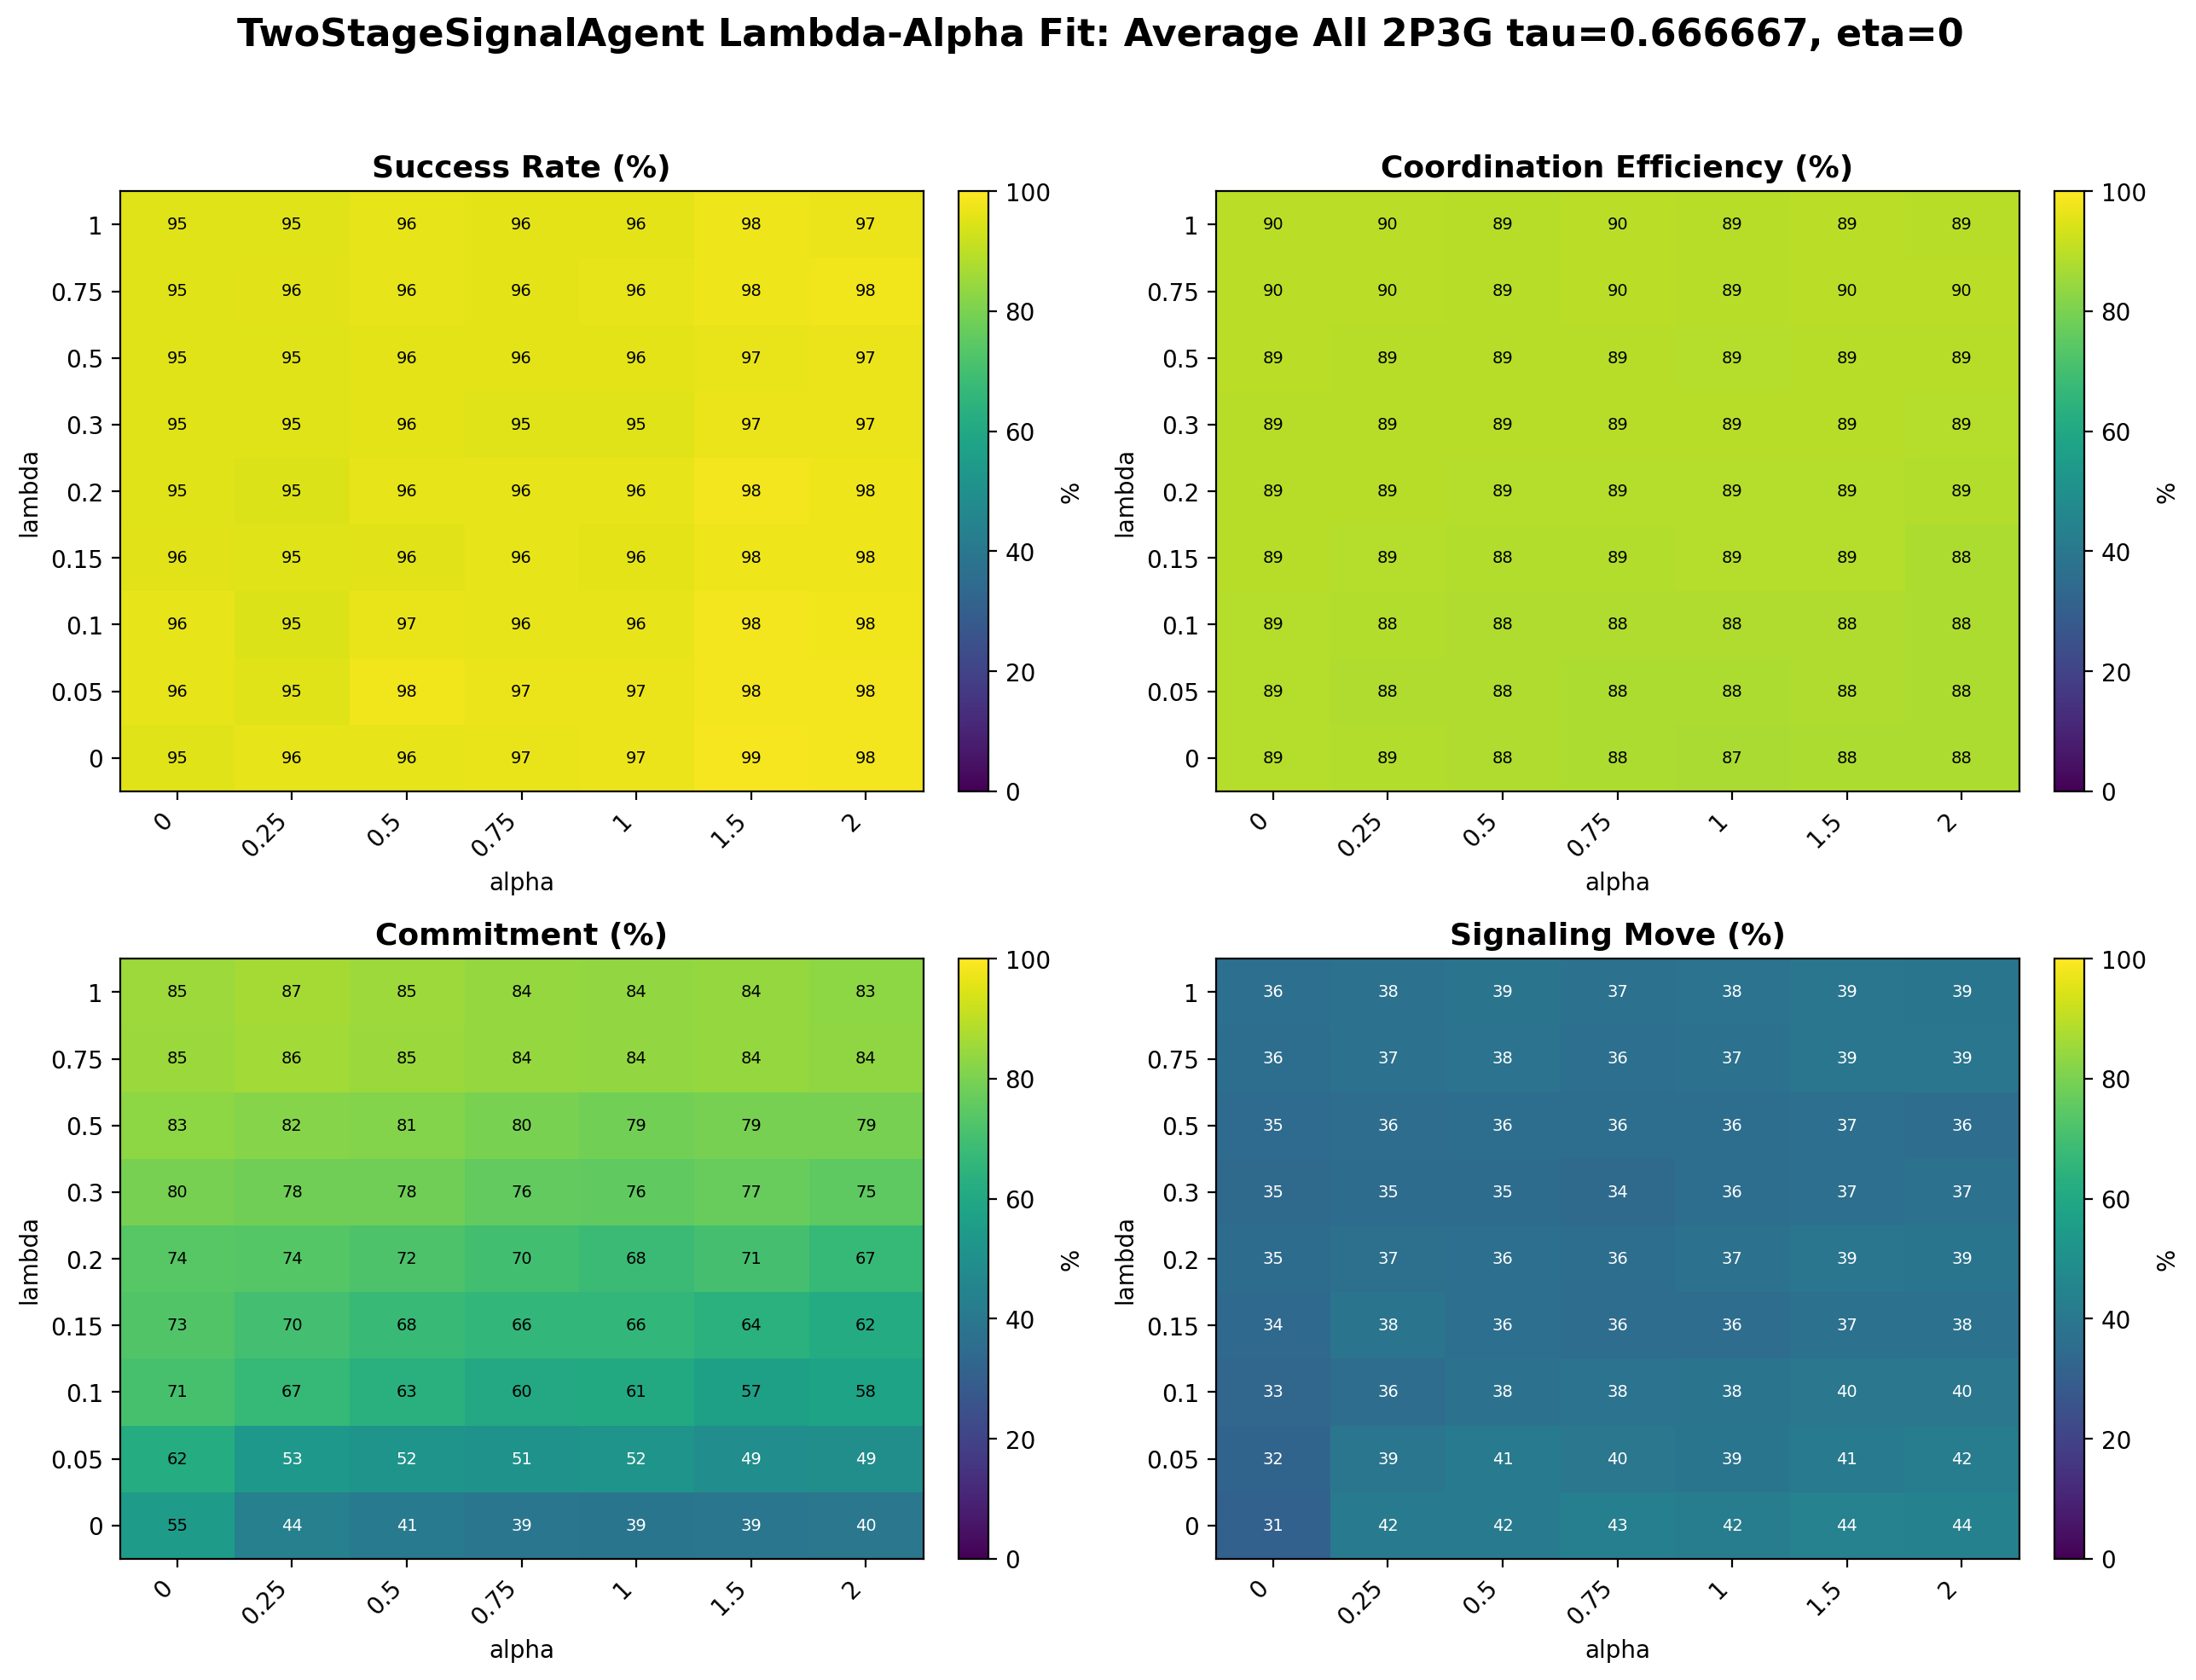

### Equal-to-both only

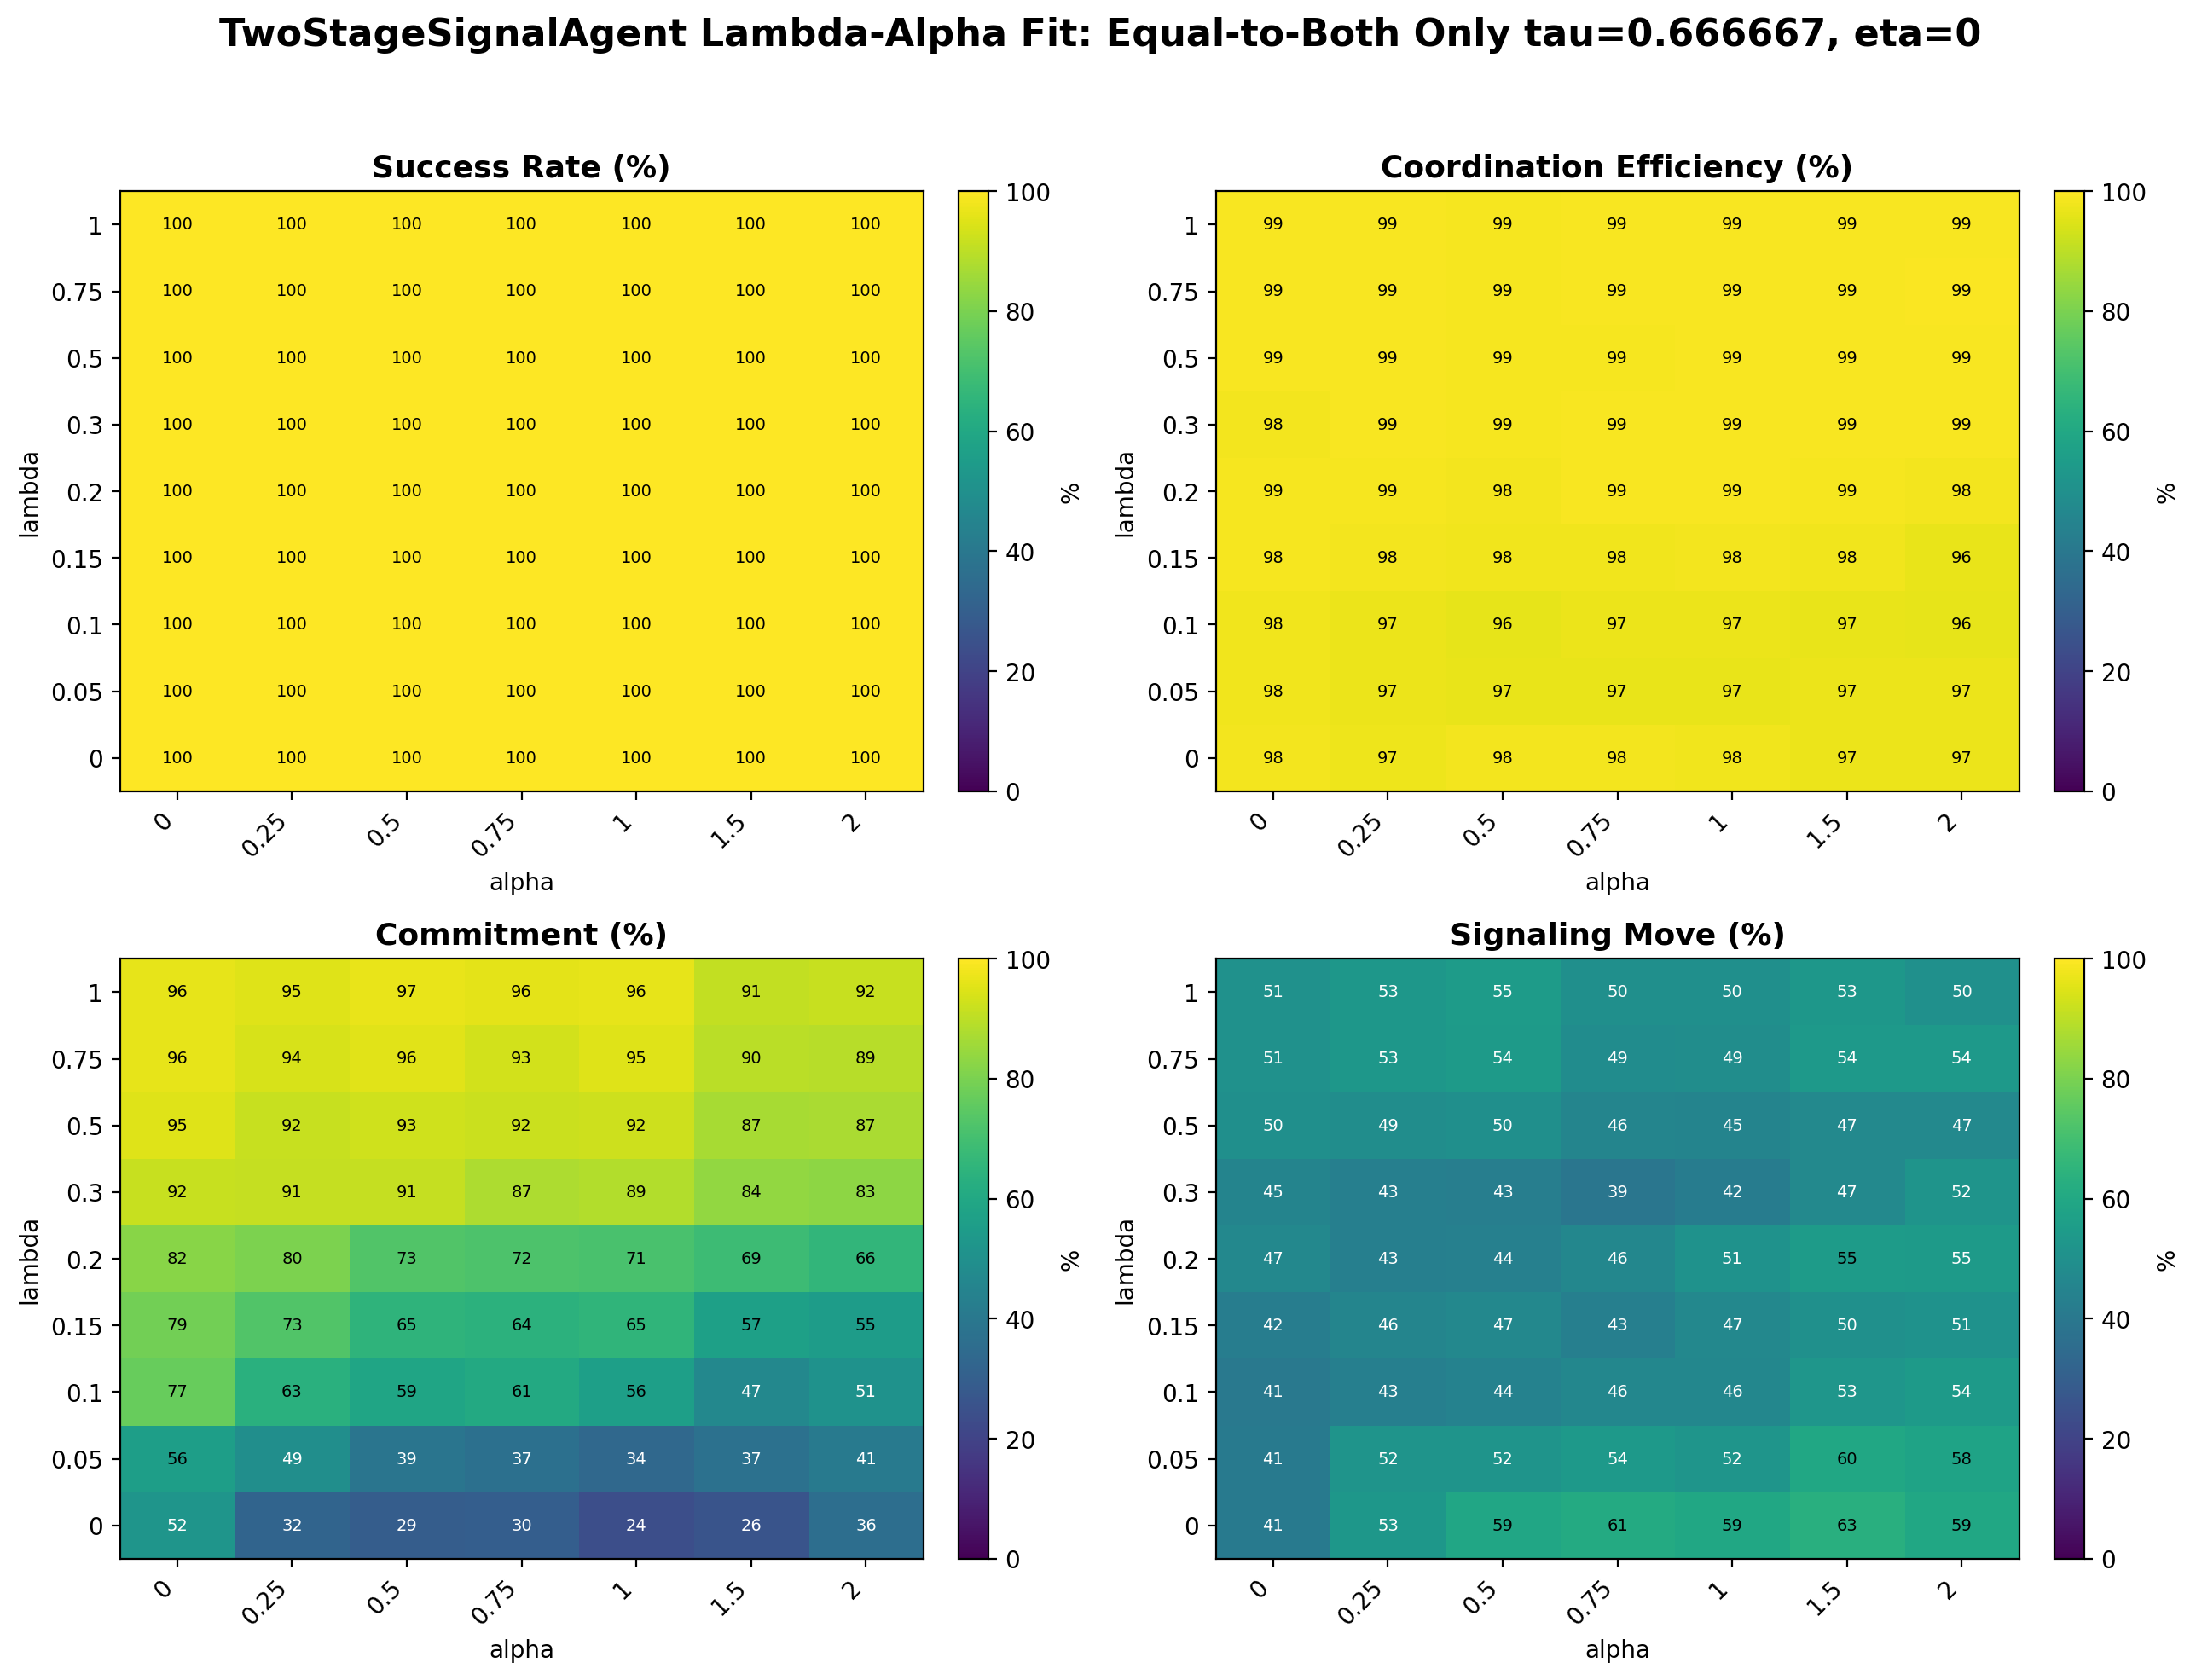

In [4]:
for filename, title in [
    ('two_stage_signal_lambda_alpha_average_4measure_heatmaps.png', 'Average across all 2P3G distance conditions'),
    ('two_stage_signal_lambda_alpha_equal_to_both_4measure_heatmaps.png', 'Equal-to-both only'),
]:
    display(Markdown(f'### {title}'))
    display(Image(filename=str(OUT / filename)))

## Best-Fit Four-Measure Summary

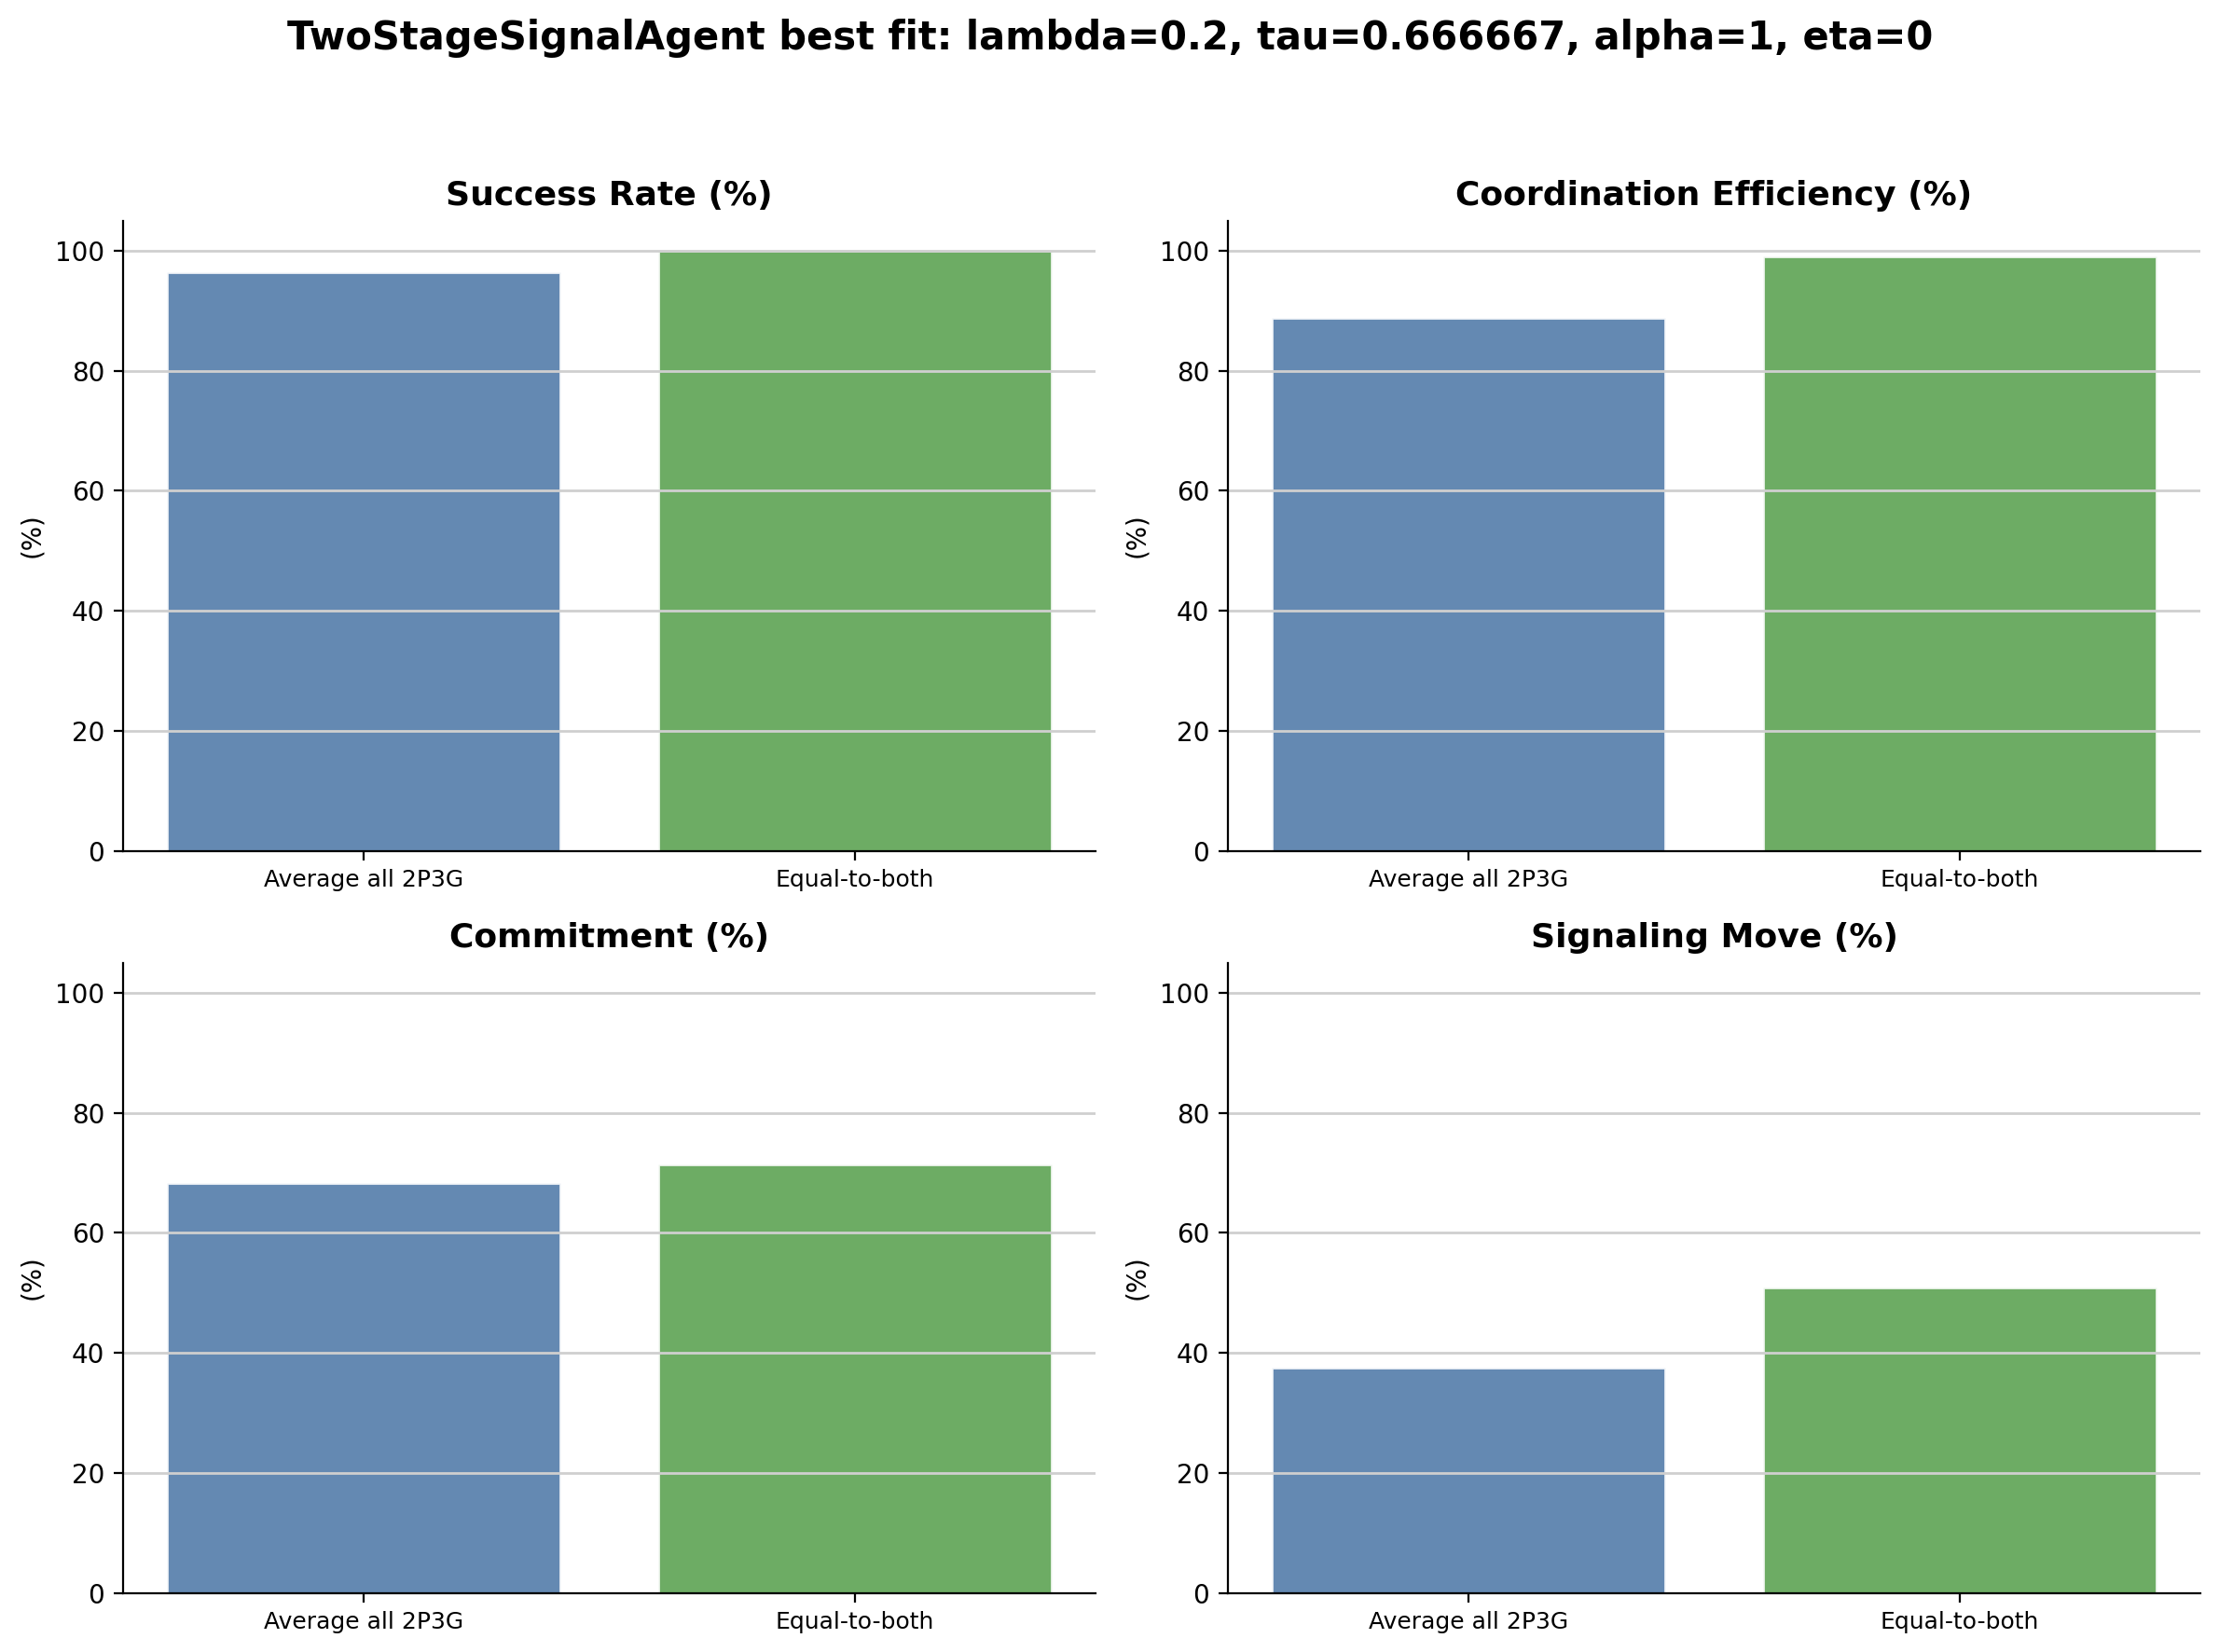

In [5]:
display(Image(filename=str(OUT / 'two_stage_signal_best_average_equal_4panel.png')))

## Best Fit Compared With Human-Human

### Average all 2P3G distance conditions

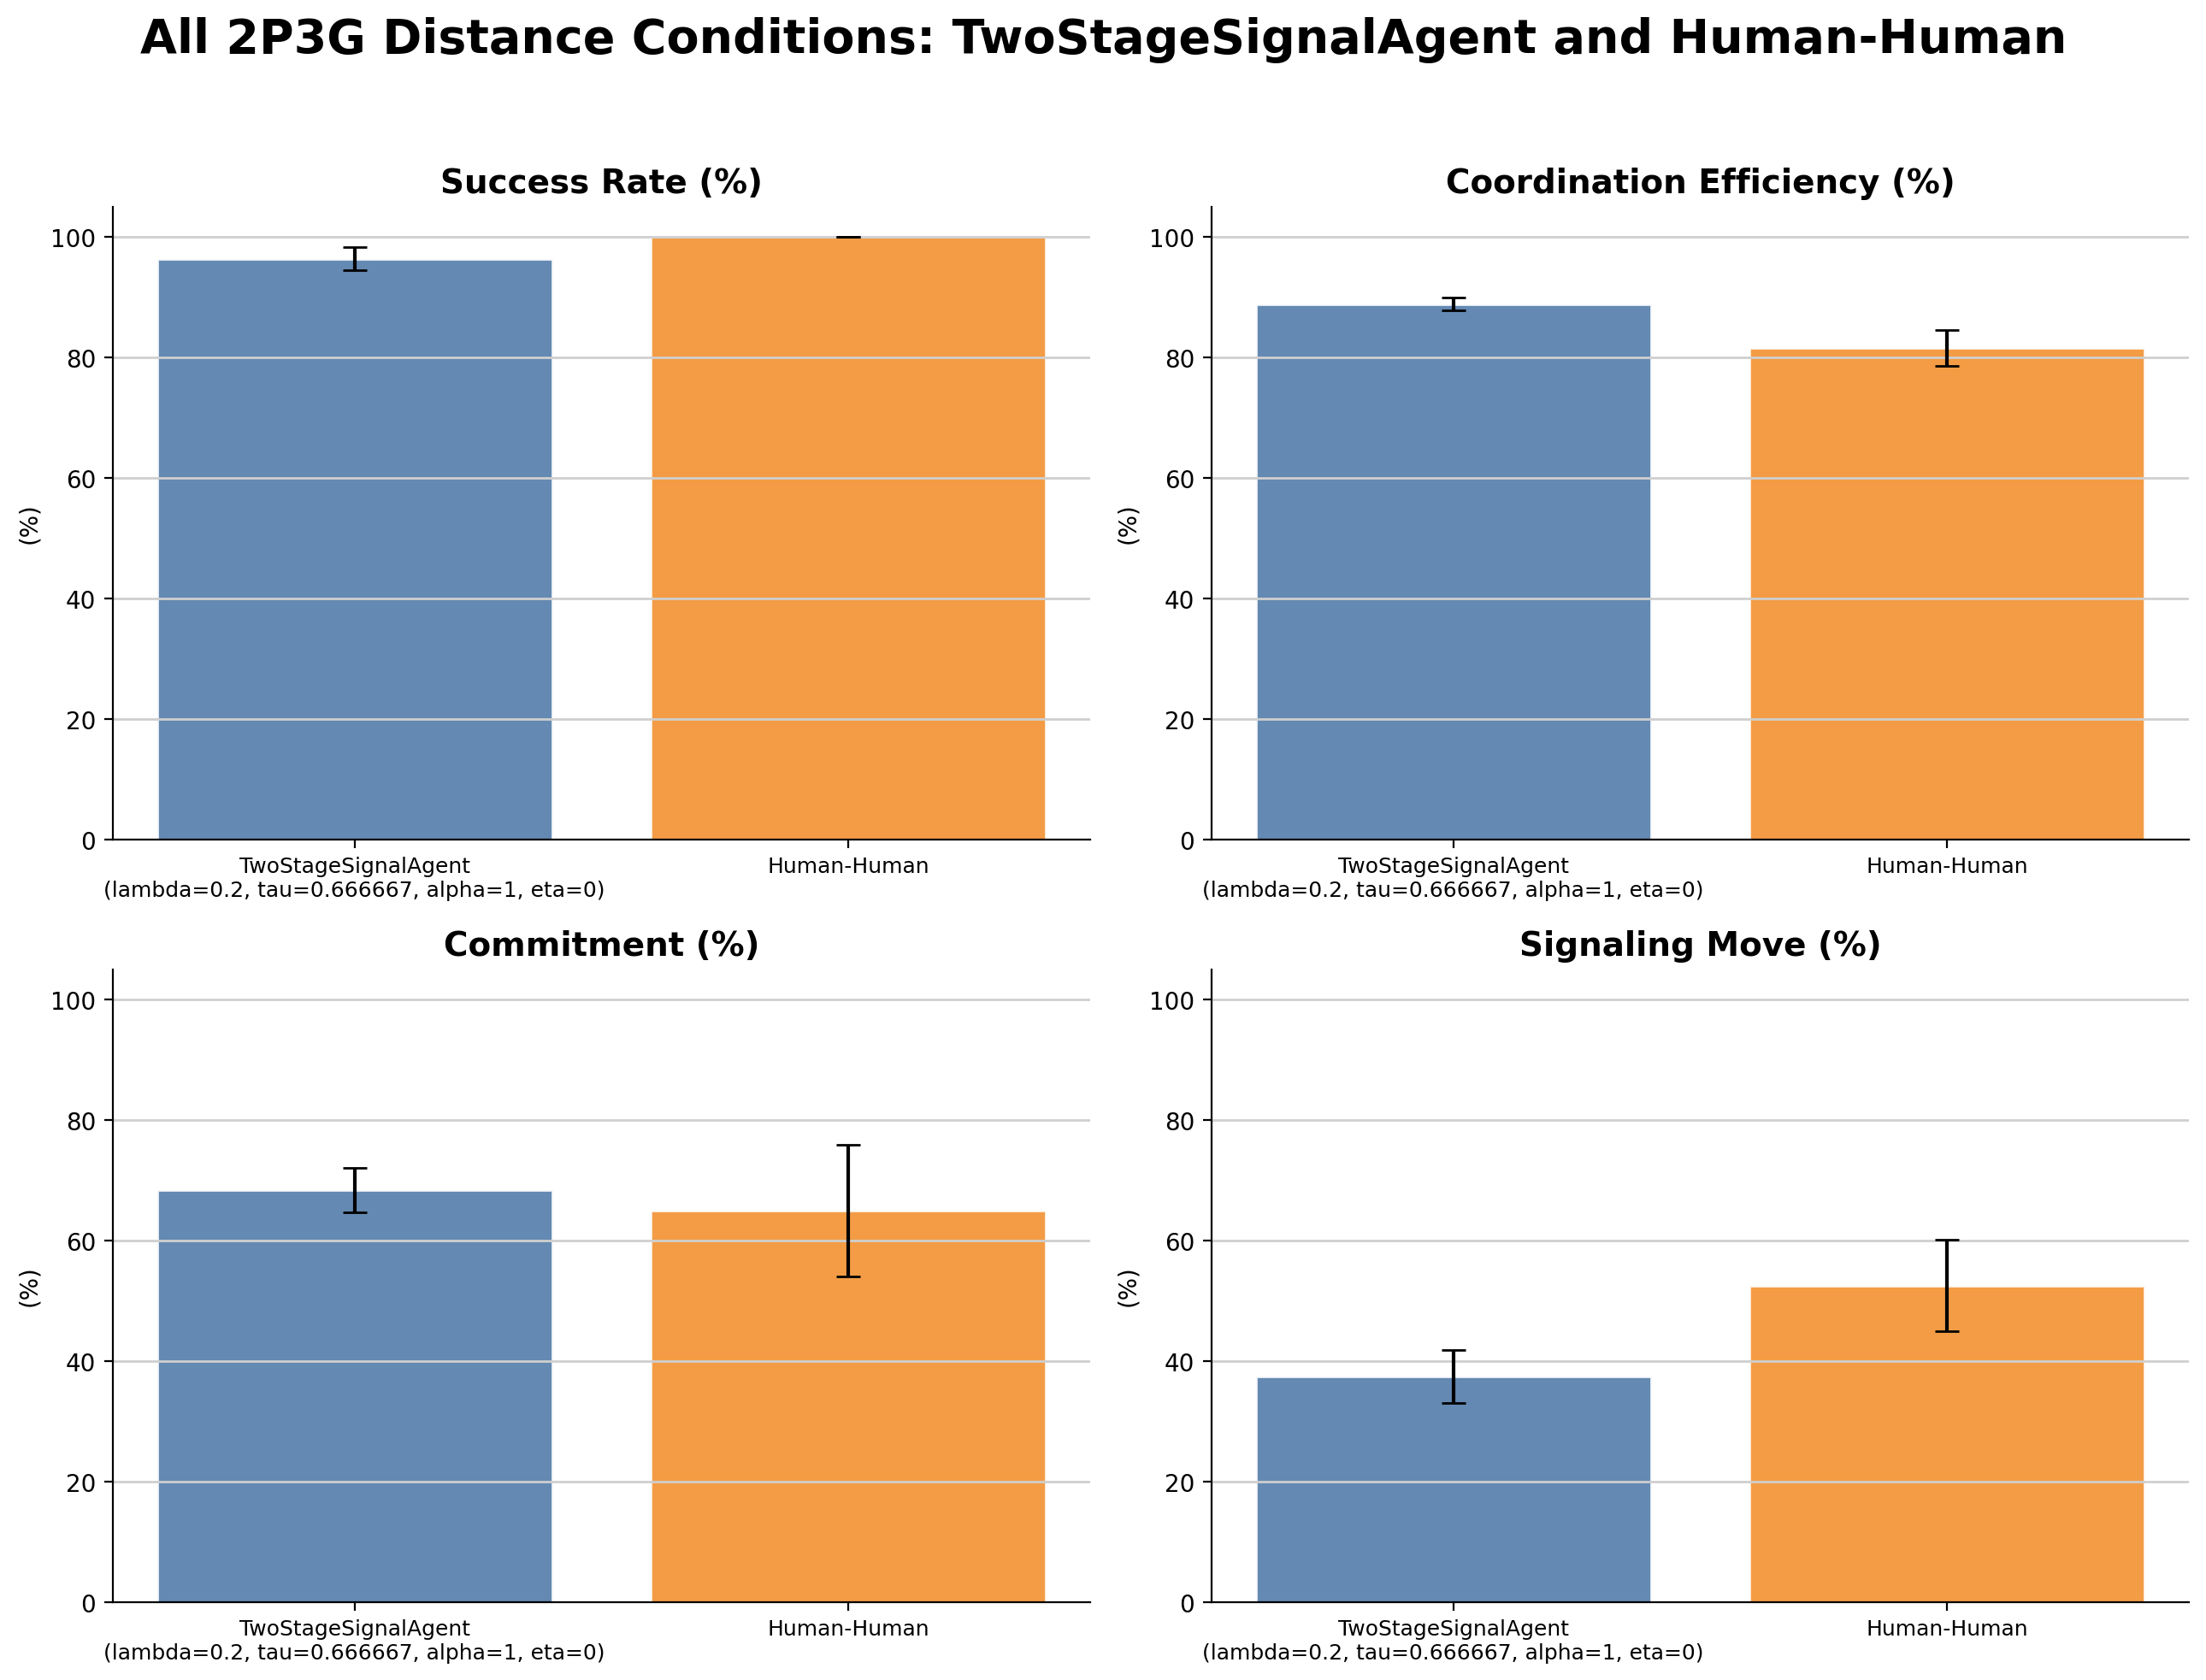

### Equal-to-both only

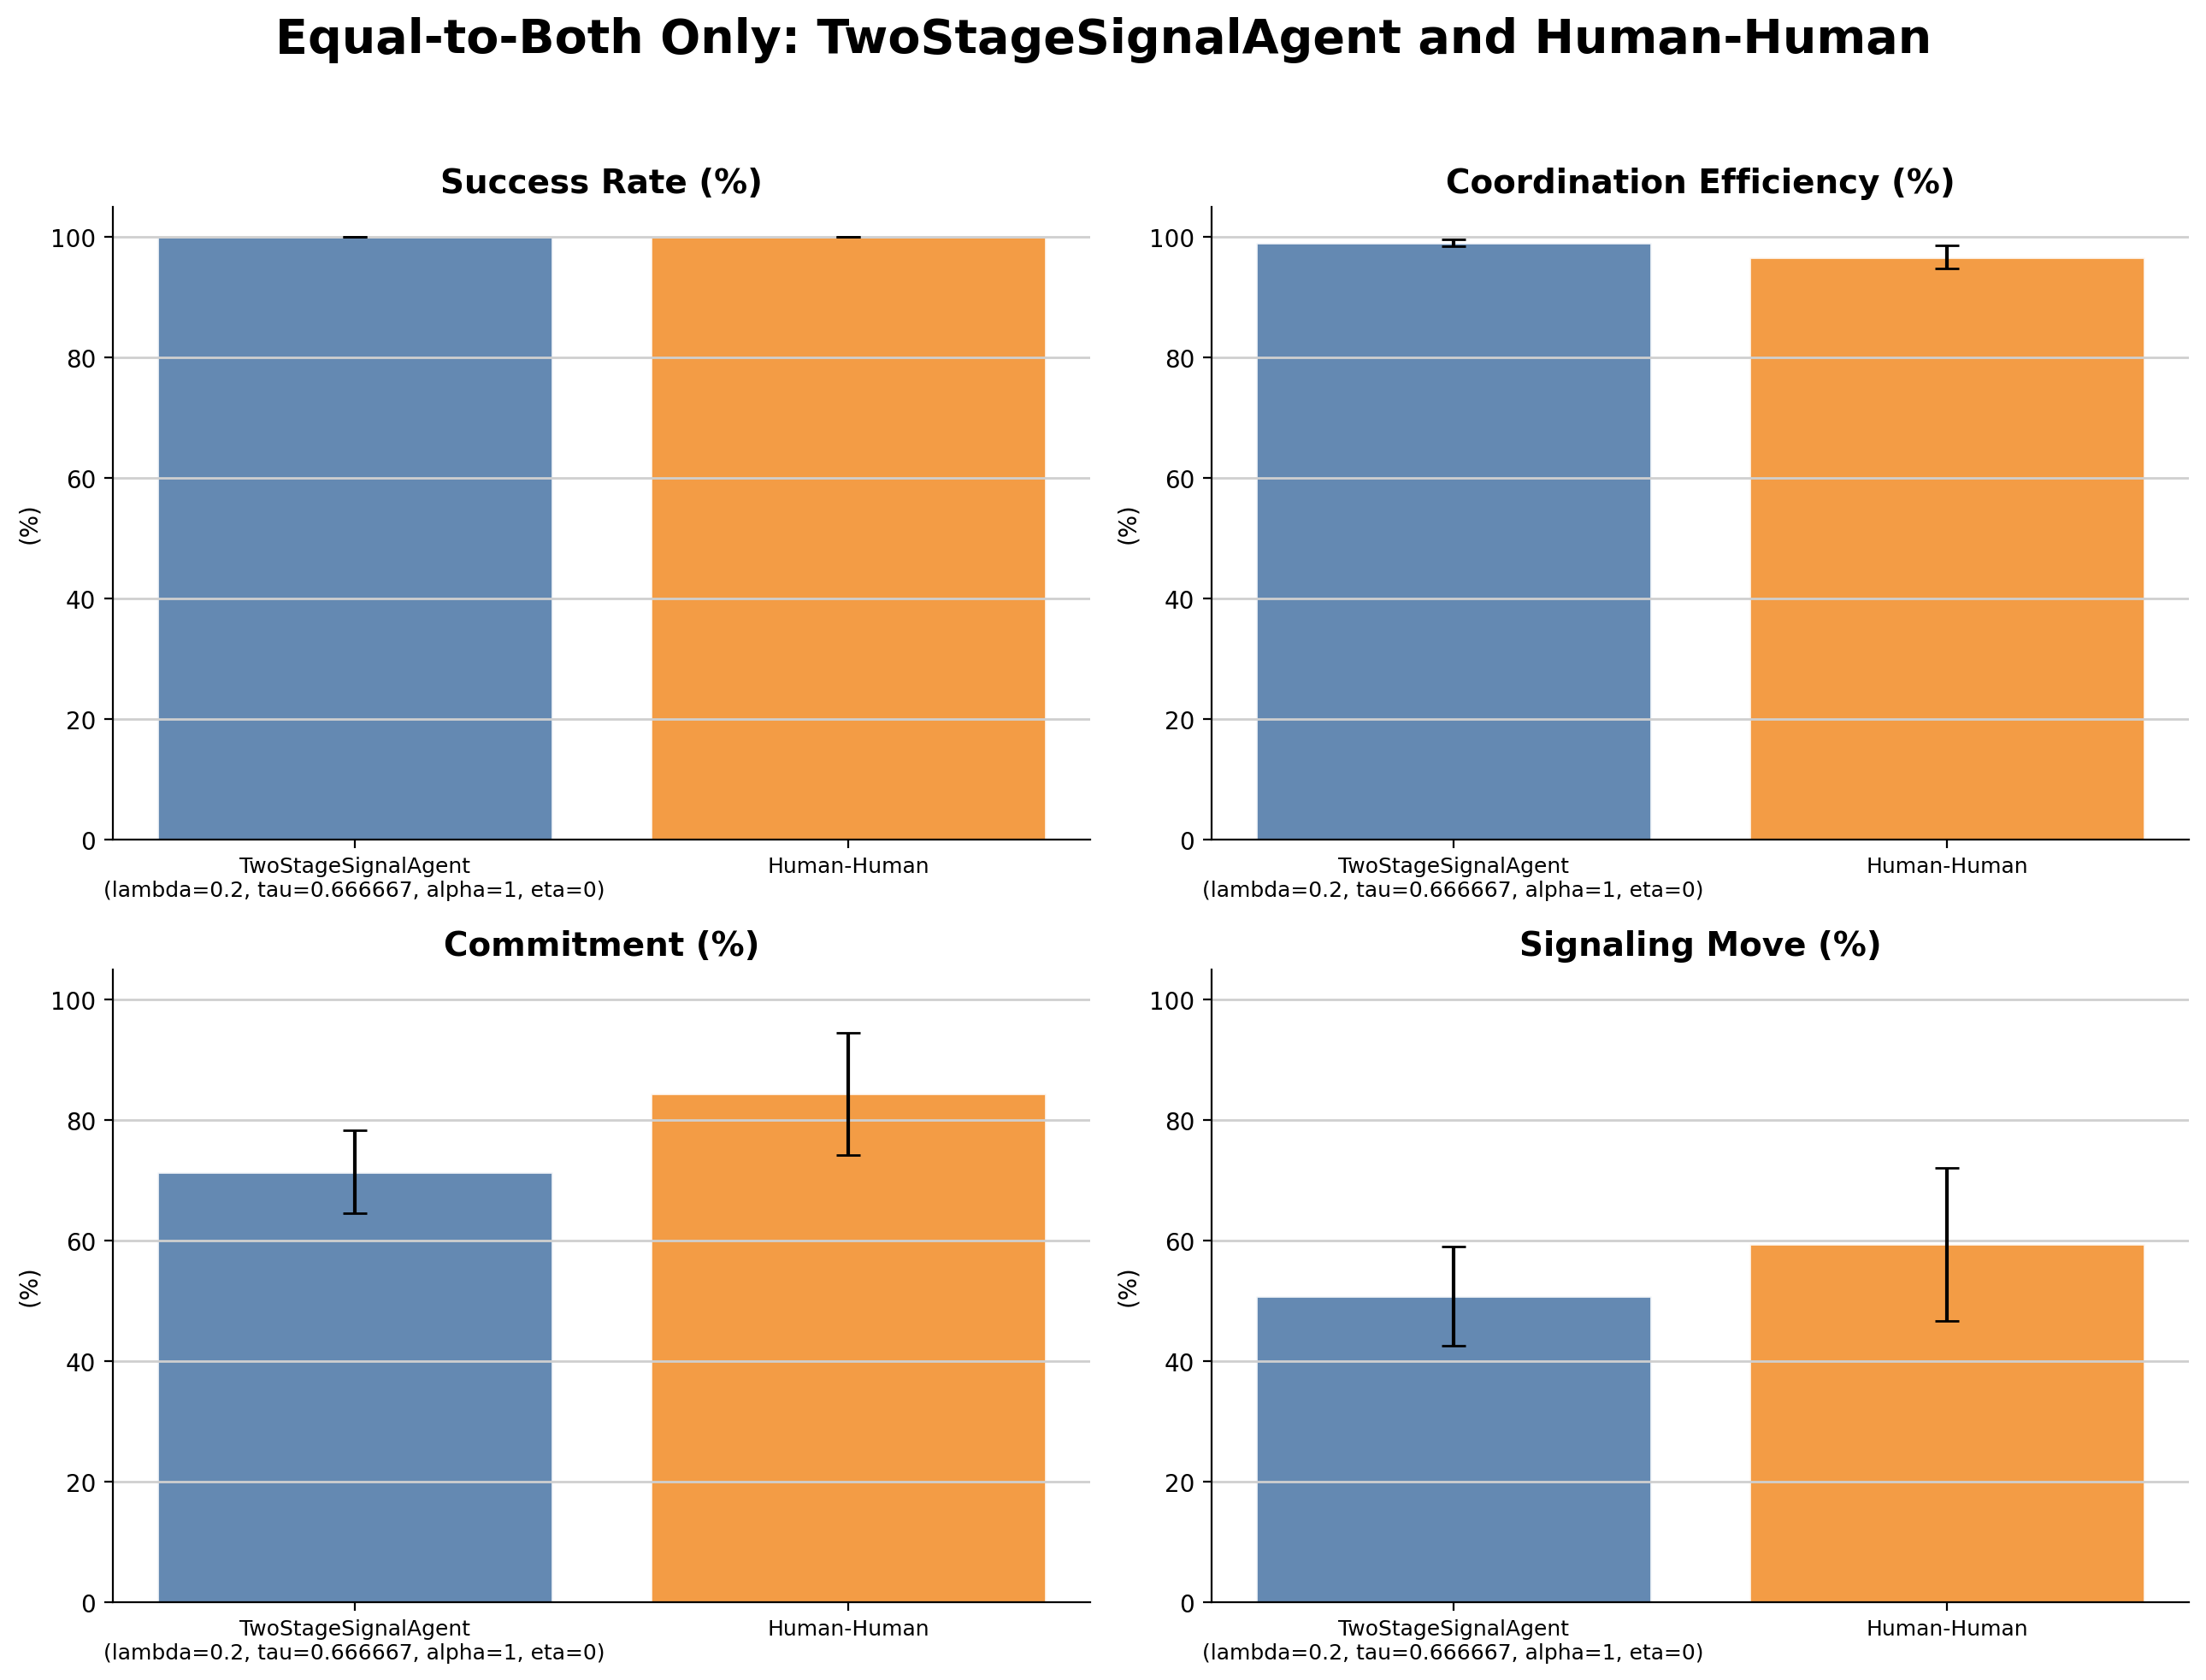

In [6]:
for filename, title in [
    ('two_stage_signal_best_vs_human_4panel_average.png', 'Average all 2P3G distance conditions'),
    ('two_stage_signal_best_vs_human_4panel_equal_to_both.png', 'Equal-to-both only'),
]:
    display(Markdown(f'### {title}'))
    display(Image(filename=str(OUT / filename)))

## Top Grid Settings

In [7]:
top_cols = [
    'lambda', 'alpha', 'tau', 'eta', 'total_nll', 'commitment_nll', 'signaling_nll',
    'average_commitment_percent', 'average_signaling_percent',
    'equal_commitment_percent', 'equal_signaling_percent',
]
display(grid.sort_values('total_nll')[top_cols].head(12).round(3))

,lambda,alpha,tau,eta,total_nll,commitment_nll,signaling_nll,average_commitment_percent,average_signaling_percent,equal_commitment_percent,equal_signaling_percent
0,0.20,1.00,0.667,0.0,371.078,182.251,188.827,68.356,37.474,71.389,50.833
1,0.15,0.25,0.667,0.0,373.007,185.131,187.876,70.235,38.416,72.778,45.556
2,0.10,0.75,0.667,0.0,373.224,185.250,187.974,60.370,38.029,60.833,46.111
3,0.30,2.00,0.667,0.0,373.662,184.002,189.660,75.046,37.137,83.056,51.667
4,0.20,0.25,0.667,0.0,374.221,183.338,190.883,73.621,37.014,80.278,43.333
5,0.30,1.00,0.667,0.0,374.278,182.197,192.081,75.572,35.999,88.611,41.944
6,0.20,0.75,0.667,0.0,374.764,184.311,190.453,69.815,36.273,71.944,46.111
7,0.10,0.50,0.667,0.0,375.180,186.698,188.482,63.492,37.778,58.889,44.444
8,0.10,1.00,0.667,0.0,375.729,188.635,187.095,60.589,38.419,56.389,46.389
9,0.20,2.00,0.667,0.0,375.854,188.127,187.727,67.184,38.679,65.805,54.598


## Effect Curves Around the Best Fit

The plots below slice the grid through the best \(\alpha\) and best \(\lambda\), showing how the two fitted parameters affect commitment and signaling.

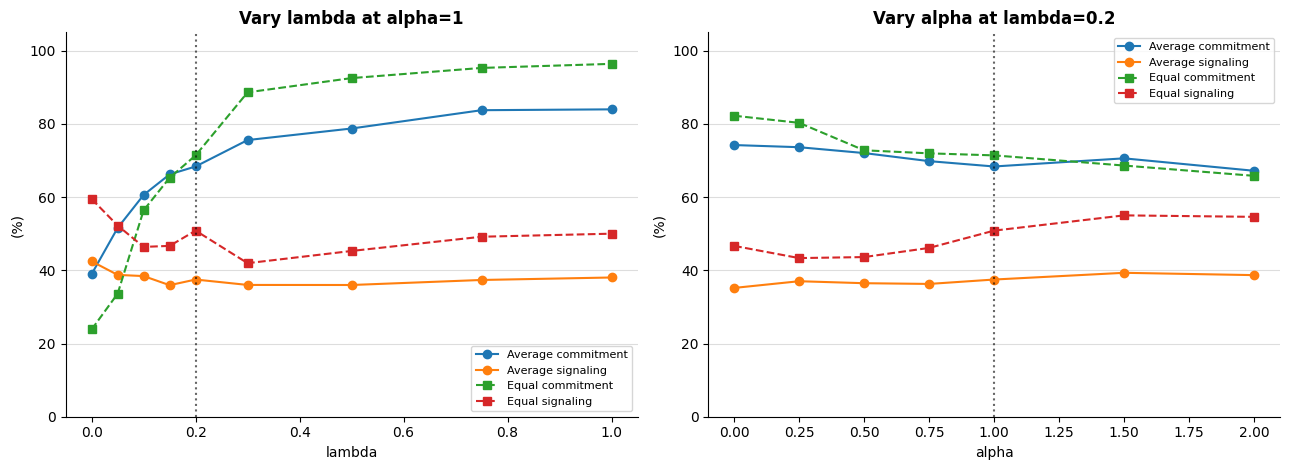

In [8]:
best_lambda = float(best['lambda'])
best_alpha = float(best['alpha'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sub_alpha = grid[np.isclose(grid['alpha'], best_alpha)].sort_values('lambda')
axes[0].plot(sub_alpha['lambda'], sub_alpha['average_commitment_percent'], marker='o', label='Average commitment')
axes[0].plot(sub_alpha['lambda'], sub_alpha['average_signaling_percent'], marker='o', label='Average signaling')
axes[0].plot(sub_alpha['lambda'], sub_alpha['equal_commitment_percent'], marker='s', linestyle='--', label='Equal commitment')
axes[0].plot(sub_alpha['lambda'], sub_alpha['equal_signaling_percent'], marker='s', linestyle='--', label='Equal signaling')
axes[0].axvline(best_lambda, color='black', linestyle=':', alpha=0.6)
axes[0].set_title(f'Vary lambda at alpha={best_alpha:g}', fontweight='bold')
axes[0].set_xlabel('lambda')
axes[0].set_ylabel('(%)')
axes[0].set_ylim(0, 105)
axes[0].grid(axis='y', color='#dddddd')
axes[0].legend(fontsize=8)

sub_lambda = grid[np.isclose(grid['lambda'], best_lambda)].sort_values('alpha')
axes[1].plot(sub_lambda['alpha'], sub_lambda['average_commitment_percent'], marker='o', label='Average commitment')
axes[1].plot(sub_lambda['alpha'], sub_lambda['average_signaling_percent'], marker='o', label='Average signaling')
axes[1].plot(sub_lambda['alpha'], sub_lambda['equal_commitment_percent'], marker='s', linestyle='--', label='Equal commitment')
axes[1].plot(sub_lambda['alpha'], sub_lambda['equal_signaling_percent'], marker='s', linestyle='--', label='Equal signaling')
axes[1].axvline(best_alpha, color='black', linestyle=':', alpha=0.6)
axes[1].set_title(f'Vary alpha at lambda={best_lambda:g}', fontweight='bold')
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('(%)')
axes[1].set_ylim(0, 105)
axes[1].grid(axis='y', color='#dddddd')
axes[1].legend(fontsize=8)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.tight_layout()
plt.show()

## Takeaway

With \(\tau=2/3\) fixed and \(\eta=0\), the best setting is:

\[
\lambda=0.20,\quad \alpha=1.00
\]

This simplified model keeps early behavior as ordinary joint-RL and uses only posterior goal weighting plus signaling strength as free parameters.